In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class YieldCurveProcessor:
    def __init__(self):
        """Initialize YieldCurveProcessor"""
        # Initialize a_i and b_i parameters (these are fixed for all calculations)
        self._initialize_ab_params()
    
    def _initialize_ab_params(self):
        """Initialize a_i and b_i parameters used in the GT function"""
        self.a_values = np.zeros(9)
        self.b_values = np.zeros(9)
        
        # Initialize first values
        self.a_values[0] = 0  # a_1 = 0
        self.a_values[1] = 0.6  # a_2 = 0.6
        self.b_values[0] = self.a_values[1]  # b_1 = a_2

        k = 1.6  # parameter for recurrent calculation

        # Recurrent calculation of a_i and b_i
        for i in range(2, 9):
            self.a_values[i] = self.a_values[i - 1] + k**(i - 1)
            self.b_values[i - 1] = self.b_values[i - 2] * k
    
    def GT(self, t, beta0, beta1, beta2, tau, g_values):
        """
        Calculate continuous yield (непрерывная доходность)
        """
        t = np.asarray(t)
        
        # Main terms of the model
        term1 = beta0 + beta1 * tau * (1 - np.exp(-t / tau)) / t 
        term2 = beta2 * ((1 - np.exp(-t / tau)) * tau / t - np.exp(-t / tau))

        # Calculate sum of exponential terms
        term3 = 0
        for i in range(9):
            if self.b_values[i] != 0:
                term3 += g_values[i] * np.exp(-((t - self.a_values[i])**2) / (self.b_values[i]**2))
        
        GT_result = term1 + term2 + term3
        
        return GT_result / 10000
    
    def spot_rate(self, t, beta0, beta1, beta2, tau, g_values):
        """
        Calculate zero-coupon yield curve in % per annum
        """
        YT = 100 * (np.exp(self.GT(t, beta0, beta1, beta2, tau, g_values)) - 1)
        return YT
    
    def discount_factor(self, t, beta0, beta1, beta2, tau, g_values):
        """
        Calculate discount factor P(0,T) for zero-coupon bond
        """
        R_T = self.GT(t, beta0, beta1, beta2, tau, g_values)
        return np.exp(-R_T * t)
    
    def forward_rate_effective(self, t_start, t_end, beta0, beta1, beta2, tau, g_values):
        """
        Calculate forward rate with annual compounding for period [t_start, t_end]
        """
        P_start = self.discount_factor(t_start, beta0, beta1, beta2, tau, g_values)
        P_end = self.discount_factor(t_end, beta0, beta1, beta2, tau, g_values)
        
        forward_continuous = (np.log(P_start) - np.log(P_end)) / (t_end - t_start)
        return 100 * (np.exp(forward_continuous) - 1)
    
    def calculate_daily_yield_curves(self, df, max_months=360, max_quarters=120):
        """
        Calculate yield curves for each day with both monthly and quarterly granularity
        
        Parameters:
        -----------
        df: DataFrame with parameters
        max_months: int - maximum months for monthly granularity
        max_quarters: int - maximum quarters for quarterly granularity
        
        Returns:
        --------
        tuple: (monthly_spot_df, monthly_forward_df, quarterly_spot_df, quarterly_forward_df, summary_df)
        """
        # Monthly horizons
        months = np.arange(1, max_months + 1)
        monthly_times = months / 12.0
        
        # Quarterly horizons  
        quarters = np.arange(1, max_quarters + 1)
        quarterly_times = quarters / 4.0  # Convert quarters to years
        
        # Prepare results DataFrames
        monthly_spot_data = {'tradedate': [], 'tradetime': [], 'month': [], 'years': [], 'spot_rate': []}
        monthly_forward_data = {'tradedate': [], 'tradetime': [], 'start_month': [], 'end_month': [], 
                               'start_year': [], 'end_year': [], 'forward_rate_12m': []}
        
        quarterly_spot_data = {'tradedate': [], 'tradetime': [], 'quarter': [], 'years': [], 'spot_rate': []}
        quarterly_forward_data = {'tradedate': [], 'tradetime': [], 'start_quarter': [], 'end_quarter': [], 
                                 'start_year': [], 'end_year': [], 'forward_rate_4q': []}
        
        summary_data = []
        
        # Process each row (each trading day)
        for idx, row in df.iterrows():
            beta0 = row['B1']
            beta1 = row['B2'] 
            beta2 = row['B3']
            tau = row['T1']
            g_values = [row[f'G{i}'] for i in range(1, 10)]
            
            tradedate = row['tradedate']
            tradetime = row['tradetime']
            
            # MONTHLY GRANULARITY CALCULATIONS
            monthly_spot_rates = self.spot_rate(monthly_times, beta0, beta1, beta2, tau, g_values)
            
            # Store monthly spot rates
            for i, month in enumerate(months):
                monthly_spot_data['tradedate'].append(tradedate)
                monthly_spot_data['tradetime'].append(tradetime)
                monthly_spot_data['month'].append(month)
                monthly_spot_data['years'].append(monthly_times[i])
                monthly_spot_data['spot_rate'].append(monthly_spot_rates[i])
            
            # ADD FORWARD RATE FROM 0 TO 12 MONTHS (1-year spot rate)
            monthly_forward_data['tradedate'].append(tradedate)
            monthly_forward_data['tradetime'].append(tradetime)
            monthly_forward_data['start_month'].append(0)
            monthly_forward_data['end_month'].append(12)
            monthly_forward_data['start_year'].append(0)
            monthly_forward_data['end_year'].append(1.0)
            monthly_forward_data['forward_rate_12m'].append(monthly_spot_rates[11])

            # Calculate 12-month forward rates (monthly starting points)
            for i, start_month in enumerate(months[:-12]):
                start_year = monthly_times[i]
                end_year = monthly_times[i + 12]
                
                forward_rate_12m = self.forward_rate_effective(
                    start_year, end_year, beta0, beta1, beta2, tau, g_values
                )
                
                monthly_forward_data['tradedate'].append(tradedate)
                monthly_forward_data['tradetime'].append(tradetime)
                monthly_forward_data['start_month'].append(start_month)
                monthly_forward_data['end_month'].append(start_month + 12)
                monthly_forward_data['start_year'].append(start_year)
                monthly_forward_data['end_year'].append(end_year)
                monthly_forward_data['forward_rate_12m'].append(forward_rate_12m)
            
            # QUARTERLY GRANULARITY CALCULATIONS
            quarterly_spot_rates = self.spot_rate(quarterly_times, beta0, beta1, beta2, tau, g_values)
            
            # Store quarterly spot rates
            for i, quarter in enumerate(quarters):
                quarterly_spot_data['tradedate'].append(tradedate)
                quarterly_spot_data['tradetime'].append(tradetime)
                quarterly_spot_data['quarter'].append(quarter)
                quarterly_spot_data['years'].append(quarterly_times[i])
                quarterly_spot_data['spot_rate'].append(quarterly_spot_rates[i])
            
            # ADD FORWARD RATE FROM 0 TO 4 QUARTERS (1-year spot rate)
            quarterly_forward_data['tradedate'].append(tradedate)
            quarterly_forward_data['tradetime'].append(tradetime)
            quarterly_forward_data['start_quarter'].append(0)
            quarterly_forward_data['end_quarter'].append(4)
            quarterly_forward_data['start_year'].append(0)
            quarterly_forward_data['end_year'].append(1.0)
            quarterly_forward_data['forward_rate_4q'].append(quarterly_spot_rates[3])

            # Calculate 1-year (4-quarter) forward rates (quarterly starting points)
            for i, start_quarter in enumerate(quarters[:-4]):
                start_year = quarterly_times[i]
                end_year = quarterly_times[i + 4]  # 4 quarters = 1 year
                
                forward_rate_4q = self.forward_rate_effective(
                    start_year, end_year, beta0, beta1, beta2, tau, g_values
                )
                
                quarterly_forward_data['tradedate'].append(tradedate)
                quarterly_forward_data['tradetime'].append(tradetime)
                quarterly_forward_data['start_quarter'].append(start_quarter)
                quarterly_forward_data['end_quarter'].append(start_quarter + 4)
                quarterly_forward_data['start_year'].append(start_year)
                quarterly_forward_data['end_year'].append(end_year)
                quarterly_forward_data['forward_rate_4q'].append(forward_rate_4q)
        
        # Create final DataFrames
        monthly_spot_df = pd.DataFrame(monthly_spot_data)
        monthly_forward_df = pd.DataFrame(monthly_forward_data)
        quarterly_spot_df = pd.DataFrame(quarterly_spot_data)
        quarterly_forward_df = pd.DataFrame(quarterly_forward_data)
        
        return monthly_spot_df, monthly_forward_df, quarterly_spot_df, quarterly_forward_df

In [17]:
# Load your data
df = pd.read_csv('input/yieldcurve.csv', sep=';', skiprows=2, decimal=',', 
                 parse_dates=['tradedate'], date_format="%d.%m.%Y")
df_selected = df[['tradedate', 'tradetime', 'B1', 'B2', 'B3', 'T1', 
                 'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9']]

# Create processor
processor = YieldCurveProcessor()

# Calculate daily yield curves with monthly granularity
monthly_spot_df, monthly_forward_df, quarterly_spot_df, quarterly_forward_df = processor.calculate_daily_yield_curves(
    df_selected,
    max_months=int(4*12),
    max_quarters=int(4*4)
)

monthly_spot_matrix = monthly_spot_df.pivot(index='tradedate', columns='month', values='spot_rate')
monthly_forward_matrix = monthly_forward_df.pivot(index='tradedate', columns='start_month', values='forward_rate_12m')

quarterly_spot_matrix = quarterly_spot_df.pivot(index='tradedate', columns='quarter', values='spot_rate')
quarterly_forward_matrix = quarterly_forward_df.pivot(index='tradedate', columns='start_quarter', values='forward_rate_4q')

In [27]:
# Save to Excel with different sheets
with pd.ExcelWriter('input/yieldcurves.xlsx') as writer:
    monthly_spot_matrix.to_excel(writer, sheet_name='monthly_spot')
    monthly_forward_matrix.to_excel(writer, sheet_name='monthly_forward')
    quarterly_spot_matrix.to_excel(writer, sheet_name='quarterly_spot')
    quarterly_forward_matrix.to_excel(writer, sheet_name='quarterly_forward')

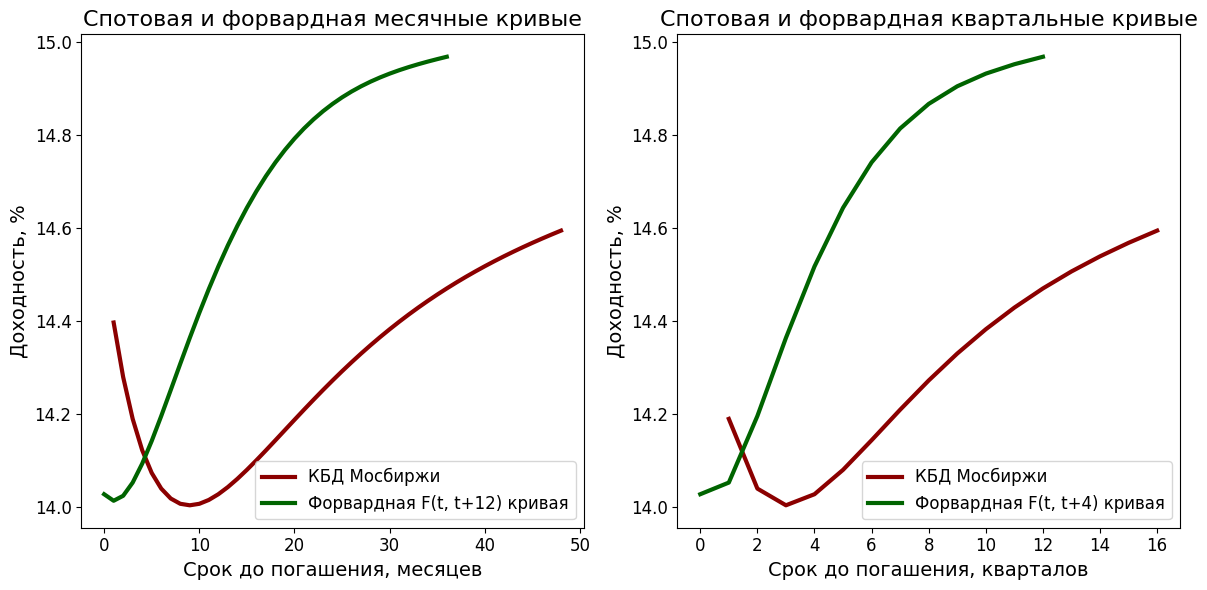

In [20]:
# Построение графика
fig, ax = plt.subplots(1,2, figsize=(12, 6))
idx = -5

ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[0].plot(monthly_spot_matrix.iloc[idx].index, monthly_spot_matrix.iloc[idx].values, label='КБД Мосбиржи' ,linewidth=3, linestyle='-',color = 'darkred')
ax[0].plot(monthly_forward_matrix.iloc[idx].index, monthly_forward_matrix.iloc[idx].values, label='Форвардная F(t, t+12) кривая',linewidth=3, linestyle='-',color = 'darkgreen')
ax[0].set_title('Спотовая и форвардная месячные кривые',fontsize=16)
ax[0].set_xlabel('Срок до погашения, месяцев',fontsize=14)
ax[0].set_ylabel('Доходность, %',fontsize=14)
ax[0].grid(False)
ax[0].legend(fontsize=12)

ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[1].plot(quarterly_spot_matrix.iloc[idx].index, quarterly_spot_matrix.iloc[idx].values, label='КБД Мосбиржи' ,linewidth=3, linestyle='-',color = 'darkred')
ax[1].plot(quarterly_forward_matrix.iloc[idx].index, quarterly_forward_matrix.iloc[idx].values, label='Форвардная F(t, t+4) кривая',linewidth=3, linestyle='-',color = 'darkgreen')
ax[1].set_title('Спотовая и форвардная квартальные кривые',fontsize=16)
ax[1].set_xlabel('Срок до погашения, кварталов',fontsize=14)
ax[1].set_ylabel('Доходность, %',fontsize=14)
ax[1].grid(False)
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()